# NYC Taxi Tip Likelihood — v2 Tuned Model

- Caleb Solomons
- Mubeen Yaqub
- Mai Lam
- Anh Minh Tran

**DSCI 592 Capstone — Team GridRunners**
**Target:** `tipped` (binary classification — `int(tip_amount > 0)`)

Regression head becomes a binary classification head. Everything from data load through feature engineering through stratified sampling is shared; the diffs sit in four places:

1. **Target** — `tipped` (already in the cleaned parquet, no derivation needed).
2. **Objective** — `binary:logistic` with `logloss` as the Optuna metric. We optimize for calibrated probabilities, not ranking — the Streamlit UI displays the raw probability and "85%" should genuinely mean 85%.
3. **Sanity bounds** — no target bounds (binary). Distance bounds match fare/duration so the training distribution stays consistent across all four models.
4. **Deck artifacts** — ROC + AP curves replace pred-vs-actual; **calibration plot replaces residuals** (this is the methodological centerpiece — see the note below).

**Methodological note (read this before training):** The `tipped` target is derived from TLC `tip_amount`, which is only populated for credit-card transactions. Cash tips are never recorded. Deliberately did *not* filter to credit-card trips — at booking time the payment method is the rider's choice and not predictable. The predicted probability therefore reads as "historical fraction of trips like this that ended in a recorded tip," capturing payment behavior and tipping behavior jointly.

Output: `xgb_v2_tip.json` — loaded directly by `gridrunners_demo.py` via `predict_tip_probability`.

## 1. Setup

In [ ]:
!pip -q install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.0 MB/s eta 0:00:00


In [ ]:
import json
import math
import warnings
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, log_loss, brier_score_loss,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve, confusion_matrix,
)
from sklearn.calibration import calibration_curve


import xgboost as xgb

import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["savefig.bbox"] = "tight"

sns.set_style("whitegrid")

print(f"pandas {pd.__version__} | numpy {np.__version__} | xgboost {xgb.__version__} | optuna {optuna.__version__}")

pandas 2.2.2 | numpy 2.0.2 | xgboost 3.2.0 | optuna 4.8.0


## 2. Config Tuning

Default threshold for confusion-matrix style metrics is 0.5; the deployed Streamlit UI displays the raw probability and never thresholds.

In [ ]:
SAMPLE_SIZE = 1_500_000
TUNING_SAMPLE = 250_000
USE_FULL_DATASET = False 

N_TRIALS = 30
CV_FOLDS = 5

DIST_MIN, DIST_MAX = 0.3, 50.0

DEFAULT_THRESHOLD = 0.5

ENABLE_WEATHER_JOIN = True
ENABLE_EVENT_FLAGS  = True
ENABLE_DISTANCE_PROXIES = True

XGB_DEVICE = "cuda" 

## 3. Mount Drive & Set Paths

In [4]:
from google.colab import drive
drive.mount("/content/drive")

DRIVE_BASE  = Path("/content/drive/MyDrive/DSCI 592")
DATA_PATH   = Path("/content/drive/MyDrive/DSCI 592/2023_Yellow_Taxi_Cleaned.parquet")

OUTPUT_DIR  = DRIVE_BASE / "v2_tuned_tip"
FIGURE_DIR  = OUTPUT_DIR / "figures"
METRICS_DIR = OUTPUT_DIR / "metrics"

for d in (OUTPUT_DIR, FIGURE_DIR, METRICS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Reading data from : {DATA_PATH}")
print(f"Saving outputs to : {OUTPUT_DIR}")

Mounted at /content/drive
Reading data from : /content/drive/MyDrive/DSCI 592/2023_Yellow_Taxi_Cleaned.parquet
Saving outputs to : /content/drive/MyDrive/DSCI 592/v2_tuned_tip


## 4. Load Data & Inspect Columns

In [ ]:
df_full = pd.read_parquet(DATA_PATH)

print(f"Full dataset shape : {df_full.shape[0]:,} rows × {df_full.shape[1]} cols")
print(f"Memory footprint   : {df_full.memory_usage(deep=True).sum() / 1e9:.2f} GB\n")
print("Columns and dtypes:")
print(df_full.dtypes.to_string())

print(f"\nTarget `tipped` distribution:")
print(df_full["tipped"].value_counts(normalize=True).round(4).to_string())
print(f"  → ~{df_full['tipped'].mean():.1%} positive class (mild imbalance, no class weighting needed)")

Full dataset shape : 37,017,621 rows × 35 cols
Memory footprint   : 29.12 GB

Columns and dtypes:
VendorID                          int64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
trip_duration_min               float64
speed_mph                       float64
pickup_hour                       int32
pickup_dow            

## 5. Column Mapping & Leakage Discipline

The feature same `build_feature_row` in the Streamlit app feeds all four models.

**Critical leakage exclusions for tip:**
-`tip_amount` — *is* the target. Excluded.
-`total_amount` — includes the tip. Would leak the target completely.
-`fare_amount` — also post-trip; the meter resolves it during the ride.
-`payment_type` — by deliberate choice (see methodological note in cell 0 and Section 22). Even though `payment_type` is technically known at trip end, the consumer-facing question is "will a trip like this be tipped?" without prejudging payment method.

**Target swap:** `tipped` instead of `fare_amount` / `trip_duration_min`. Already a clean int 0/1 from the cleaning notebook's `df["tipped"] = (df["tip_amount"] > 0).astype(int)` — no derivation needed here.

In [ ]:
COL = {
    "target":         "tipped",   # <<< binary classification target
    "trip_distance":  "trip_distance",
    "passengers":     "passenger_count",
    "hour":           "pickup_hour",
    "dow":            "pickup_dow",
    "weekend":        "is_weekend",
    "pu_borough":     "PU_borough",
    "do_borough":     "DO_borough",
    "vendor":         "VendorID",
    "pickup_dt":      "tpep_pickup_datetime",
    "ratecode":       "RatecodeID",
}


NUMERIC_BASE     = [COL["trip_distance"], COL["passengers"]]
CATEGORICAL_BASE = [COL["hour"], COL["dow"], COL["weekend"],
                    COL["pu_borough"], COL["do_borough"], COL["vendor"],
                    COL["ratecode"]]
TARGET = COL["target"]

ENG_NUMERIC     = []
ENG_CATEGORICAL = []

needed = set(NUMERIC_BASE + CATEGORICAL_BASE + [TARGET, COL["pickup_dt"]])
missing = sorted(needed - set(df_full.columns))

if missing:
    raise KeyError(f"Missing columns — fix COL mapping: {missing}")

print("All expected columns present. Proceeding.")

All expected columns present. Proceeding.


## 6. Filter

Lighter than fare / duration — no target bounds because the target is binary. Keep the distance bounds to stay in the same in-distribution regime as the regression models.

In [7]:
mask = (
    df_full[COL["trip_distance"]].between(DIST_MIN, DIST_MAX)
    & df_full[COL["ratecode"]].notna()
    & df_full[TARGET].isin([0, 1])
    & df_full[NUMERIC_BASE + CATEGORICAL_BASE + [TARGET, COL["pickup_dt"]]].notna().all(axis=1)
)

df_clean = df_full.loc[mask, NUMERIC_BASE + CATEGORICAL_BASE + [TARGET, COL["pickup_dt"]]].copy()
df_clean[COL["ratecode"]] = df_clean[COL["ratecode"]].astype("int8")
df_clean[TARGET] = df_clean[TARGET].astype("int8")

dropped = (~mask).sum()
print(f"Rows dropped by filter : {dropped:,} ({dropped / len(df_full):.2%})")
print(f"Rows remaining         : {len(df_clean):,}")
print(f"\nTarget balance (post-filter):")
print(f"  P(tipped=1) = {df_clean[TARGET].mean():.4f}")

Rows dropped by filter : 1,922,882 (5.19%)
Rows remaining         : 35,094,739

Target balance (post-filter):
  P(tipped=1) = 0.7861


## 7. Feature Engineering — Pillar 1: Event-Day Flags


In [ ]:
from pandas.tseries.holiday import USFederalHolidayCalendar

holidays_2023 = pd.DatetimeIndex(
    USFederalHolidayCalendar().holidays(start="2023-01-01", end="2023-12-31")
).normalize()

NYC_EVENTS_2023 = pd.to_datetime([
    "2023-06-25",  # NYC Pride March
    "2023-09-10",  # US Open men's final
    "2023-11-05",  # NYC Marathon
    "2023-11-23",  # Macy's Thanksgiving Day Parade
    "2023-12-31",  # NYE Times Square
]).normalize()

if ENABLE_EVENT_FLAGS:
    pickup_date = df_clean[COL["pickup_dt"]].dt.normalize()
    
    df_clean["is_us_holiday"] = pickup_date.isin(holidays_2023).astype("int8")
    df_clean["is_nyc_event"] = pickup_date.isin(NYC_EVENTS_2023).astype("int8")

    ENG_CATEGORICAL += ["is_us_holiday", "is_nyc_event"]

    print(f"US holiday trips : {df_clean['is_us_holiday'].sum():,} "
          f"({df_clean['is_us_holiday'].mean():.2%})")
    
    print(f"NYC event trips  : {df_clean['is_nyc_event'].sum():,} "
          f"({df_clean['is_nyc_event'].mean():.2%})")
    
else:
    print("Event-day flags disabled via ENABLE_EVENT_FLAGS=False")

US holiday trips : 765,525 (2.18%)
NYC event trips  : 397,305 (1.13%)


## 8. Feature Engineering — Pillar 2: Distance Proxies

`trip_distance` is the post-trip meter distance; the geometric proxies approximate what a routing API would estimate at booking time.

- **Haversine**:
$$ d_{hav} = 2R \cdot \arcsin\!\sqrt{\sin^2\!\tfrac{\Delta\varphi}{2} + \cos\varphi_1\cos\varphi_2\sin^2\!\tfrac{\Delta\lambda}{2}} $$
where $R$ is Earth's radius (3958.8 mi), $\varphi$ is latitude in radians, $\lambda$ is longitude in radians.

- **Manhattan-L1** — taxicab distance. At NYC latitude (~40.7°N), 1° latitude ≈ 69 mi and 1° longitude ≈ 52.5 mi.

In [ ]:
BOROUGH_CENTROIDS = {
    "Manhattan":      (40.7831, -73.9712),
    "Brooklyn":       (40.6782, -73.9442),
    "Queens":         (40.7282, -73.7949),
    "Bronx":          (40.8448, -73.8648),
    "Staten Island":  (40.5795, -74.1502),
    "EWR":            (40.6895, -74.1745),
}

EARTH_R_MI = 3958.8

def _haversine_vec(lat1, lon1, lat2, lon2):

    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2

    return 2 * EARTH_R_MI * np.arcsin(np.sqrt(a))

if ENABLE_DISTANCE_PROXIES:

    pu = df_clean[COL["pu_borough"]].astype(str)
    do = df_clean[COL["do_borough"]].astype(str)

    pu_lat = pu.map(lambda b: BOROUGH_CENTROIDS.get(b, (np.nan, np.nan))[0]).to_numpy(dtype=float)
    pu_lon = pu.map(lambda b: BOROUGH_CENTROIDS.get(b, (np.nan, np.nan))[1]).to_numpy(dtype=float)
    do_lat = do.map(lambda b: BOROUGH_CENTROIDS.get(b, (np.nan, np.nan))[0]).to_numpy(dtype=float)
    do_lon = do.map(lambda b: BOROUGH_CENTROIDS.get(b, (np.nan, np.nan))[1]).to_numpy(dtype=float)

    df_clean["haversine_mi"] = _haversine_vec(pu_lat, pu_lon, do_lat, do_lon)
    df_clean["manhattan_mi"] = (np.abs(pu_lat - do_lat) * 69.0 + np.abs(pu_lon - do_lon) * 52.5)

    fb = df_clean[COL["trip_distance"]].to_numpy()

    df_clean["haversine_mi"] = np.where(np.isnan(df_clean["haversine_mi"]), fb, df_clean["haversine_mi"])
    df_clean["manhattan_mi"] = np.where(np.isnan(df_clean["manhattan_mi"]), fb, df_clean["manhattan_mi"])

    ENG_NUMERIC += ["haversine_mi", "manhattan_mi"]

    print(f"haversine_mi  — mean {df_clean['haversine_mi'].mean():.2f} mi, max {df_clean['haversine_mi'].max():.2f} mi")
    print(f"manhattan_mi  — mean {df_clean['manhattan_mi'].mean():.2f} mi, max {df_clean['manhattan_mi'].max():.2f} mi")
    
else:
    print("Distance proxies disabled via ENABLE_DISTANCE_PROXIES=False")

haversine_mi  — mean 1.32 mi, max 49.86 mi
manhattan_mi  — mean 1.69 mi, max 49.86 mi


## 9. Feature Engineering — Pillar 3: Weather Join

Daily Central Park weather joined by pickup date.

For tip specifically, weather effects are weaker than they are for duration — but rain may correlate with shorter trips dominated by commuters (lower tip rate) vs longer trips dominated by tourists (higher tip rate). Whether the booster picks this up depends on the strength of the interaction.

In [ ]:
def _synthetic_nyc_weather(year: int = 2023) -> pd.DataFrame:

    days = pd.date_range(f"{year}-01-01", f"{year}-12-31", freq="D")
    monthly_temp = [32, 35, 43, 53, 63, 72, 78, 76, 69, 58, 47, 37]

    rng = np.random.default_rng(SEED)

    temps = np.array([monthly_temp[d.month - 1] + rng.normal(0, 4) for d in days])

    precip = rng.exponential(0.12, size=len(days))
    precip[rng.random(len(days)) < 0.55] = 0.0

    return pd.DataFrame({"date": days.normalize(), "temp_f": temps, "precip_in": precip})

def _fetch_open_meteo(year: int = 2023) -> pd.DataFrame:

    import requests

    url = (
        "https://archive-api.open-meteo.com/v1/archive"
        f"?latitude=40.7831&longitude=-73.9712"
        f"&start_date={year}-01-01&end_date={year}-12-31"
        f"&daily=temperature_2m_mean,precipitation_sum"
        f"&temperature_unit=fahrenheit&precipitation_unit=inch&timezone=America/New_York"
    )

    r = requests.get(url, timeout=20)
    r.raise_for_status()

    j = r.json()["daily"]

    return pd.DataFrame({"date": pd.to_datetime(j["time"]).normalize(),
        "temp_f": j["temperature_2m_mean"],
        "precip_in": j["precipitation_sum"],
    })

if ENABLE_WEATHER_JOIN:

    try:

        weather = _fetch_open_meteo(2023)
        source = "Open-Meteo (real)"

    except Exception as e:

        print(f"  Open-Meteo unreachable ({type(e).__name__}); using synthetic climatology.")

        weather = _synthetic_nyc_weather(2023)
        source = "synthetic (fallback)"

    weather["is_rainy"] = (weather["precip_in"] > 0.1).astype("int8")

    df_clean["_pickup_date"] = df_clean[COL["pickup_dt"]].dt.normalize()

    df_clean = df_clean.merge(weather, left_on="_pickup_date", right_on="date", how="left")
    df_clean = df_clean.drop(columns=["_pickup_date", "date"])

    ENG_NUMERIC += ["temp_f", "precip_in"]
    ENG_CATEGORICAL += ["is_rainy"]

    print(f"Weather source : {source}")
    print(f"Days joined    : {weather['date'].nunique()} / 365")
    
else:
    print("Weather join disabled via ENABLE_WEATHER_JOIN=False")

Weather source : Open-Meteo (real)
Days joined    : 365 / 365


## 10. Feature Set + Native Categorical Conversion

Must match `ALL_FEATURES` in `gridrunners_demo.py` exactly — same columns, same order, same dtypes — or `xgb.Booster.predict` errors at inference time.

In [ ]:
NUMERIC_FEATURES = NUMERIC_BASE + ENG_NUMERIC
CATEGORICAL_FEATURES = CATEGORICAL_BASE + ENG_CATEGORICAL
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

for c in CATEGORICAL_FEATURES:
    df_clean[c] = df_clean[c].astype("category")

print(f"Numeric features      ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"Categorical features  ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")
print(f"Total feature count   : {len(ALL_FEATURES)}")


EXPECTED = [
    "trip_distance", "passenger_count", "haversine_mi", "manhattan_mi",
    "temp_f", "precip_in",
    "pickup_hour", "pickup_dow", "is_weekend",
    "PU_borough", "DO_borough", "VendorID", "RatecodeID",
    "is_us_holiday", "is_nyc_event", "is_rainy",
]

assert ALL_FEATURES == EXPECTED, (
    f"FEATURE SCHEMA DRIFT — Streamlit will fail at predict time.\n"
    f"  got      : {ALL_FEATURES}\n"
    f"  expected : {EXPECTED}"
)

print("\n✓ Feature schema matches gridrunners_demo.py ALL_FEATURES")

Numeric features      (6): ['trip_distance', 'passenger_count', 'haversine_mi', 'manhattan_mi', 'temp_f', 'precip_in']
Categorical features  (10): ['pickup_hour', 'pickup_dow', 'is_weekend', 'PU_borough', 'DO_borough', 'VendorID', 'RatecodeID', 'is_us_holiday', 'is_nyc_event', 'is_rainy']
Total feature count   : 16

✓ Feature schema matches gridrunners_demo.py ALL_FEATURES


## 11. Stratified Samples — Tuning + Evaluation

Stratified on `pickup_hour × PU_borough` to preserve temporal-spatial balance. The natural class balance (~65% positive) is preserved by the stratification.

In [ ]:
df_clean["_strat"] = (df_clean[COL["hour"]].astype(str) + "|" + df_clean[COL["pu_borough"]].astype(str))

def _stratified_sample(df: pd.DataFrame, n: int, seed: int) -> pd.DataFrame:

    frac = min(1.0, n / len(df))
    out = df.groupby("_strat").sample(frac=frac, random_state=seed)
    
    return out.drop(columns=["_strat"]).reset_index(drop=True)

eval_sample = _stratified_sample(df_clean, SAMPLE_SIZE,   seed=SEED)
tune_sample = _stratified_sample(df_clean, TUNING_SAMPLE, seed=SEED + 1)

print(f"Evaluation sample : {len(eval_sample):,} rows  | P(tipped=1) = {eval_sample[TARGET].mean():.4f}")
print(f"Tuning sample     : {len(tune_sample):,} rows  | P(tipped=1) = {tune_sample[TARGET].mean():.4f}")

Evaluation sample : 1,499,992 rows  | P(tipped=1) = 0.7859
Tuning sample     : 249,994 rows  | P(tipped=1) = 0.7863


## 12. Hyperparameter Sweep — Optuna over XGBoost


1. **Objective swap**: `binary:logistic` instead of `reg:squarederror`. Output is a probability ∈ [0, 1], not a fare amount.
2. **Optuna metric swap**: minimize **logloss** instead of RMSE. Since the Streamlit UI displays the raw probability ("85%" should mean 85%), calibration is what matters at deployment time.

The trade-off is worth being explicit about: a logloss-tuned model may have slightly lower AUC than an AUC-tuned model, but its probabilities will be more honest. Report both in the K-fold step so the deck can show ranking quality alongside calibration quality.

In [ ]:
def objective(trial: optuna.Trial) -> float:

    params = {
        "objective":          "binary:logistic",
        "eval_metric":        "logloss",
        "tree_method":        "hist",
        "device":             XGB_DEVICE,
        "enable_categorical": True,
        "random_state":       SEED,
        "verbosity":          0,
        # ── searched ── (identical ranges to fare/duration)
        "max_depth":        trial.suggest_int("max_depth", 4, 12),
        "learning_rate":    trial.suggest_float("learning_rate", 1e-2, 3e-1, log=True),
        "n_estimators":     trial.suggest_int("n_estimators", 200, 1500),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "gamma":            trial.suggest_float("gamma", 0.0, 5.0),
    }

    X = tune_sample[ALL_FEATURES]
    y = tune_sample[TARGET]

    X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

    model = xgb.XGBClassifier(**params, early_stopping_rounds=50, n_jobs=-1)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

    preds = model.predict_proba(X_va)[:, 1]

    return float(log_loss(y_va, preds))


study = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=SEED),
    study_name="tip_v2_tuning",
)

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("\n" + "=" * 60)
print(f" OPTUNA — best logloss: {study.best_value:.4f}  (after {N_TRIALS} trials)")
print("=" * 60)

for k, v in study.best_params.items():
    print(f"  {k:<20} {v}")

with open(METRICS_DIR / "optuna_best_params.json", "w") as f:
    
    json.dump({"best_logloss": study.best_value, "best_params": study.best_params,
               "n_trials": N_TRIALS, "tuning_sample_size": len(tune_sample)}, f, indent=2)

  0%|          | 0/30 [00:00<?, ?it/s]


 OPTUNA — best logloss: 0.4953  (after 30 trials)
  max_depth            7
  learning_rate        0.013009139040727166
  n_estimators         973
  min_child_weight     8
  subsample            0.9420520060487542
  colsample_bytree     0.7649011048051568
  reg_alpha            0.11461666860247424
  reg_lambda           2.8805052221091634
  gamma                0.669636724243669


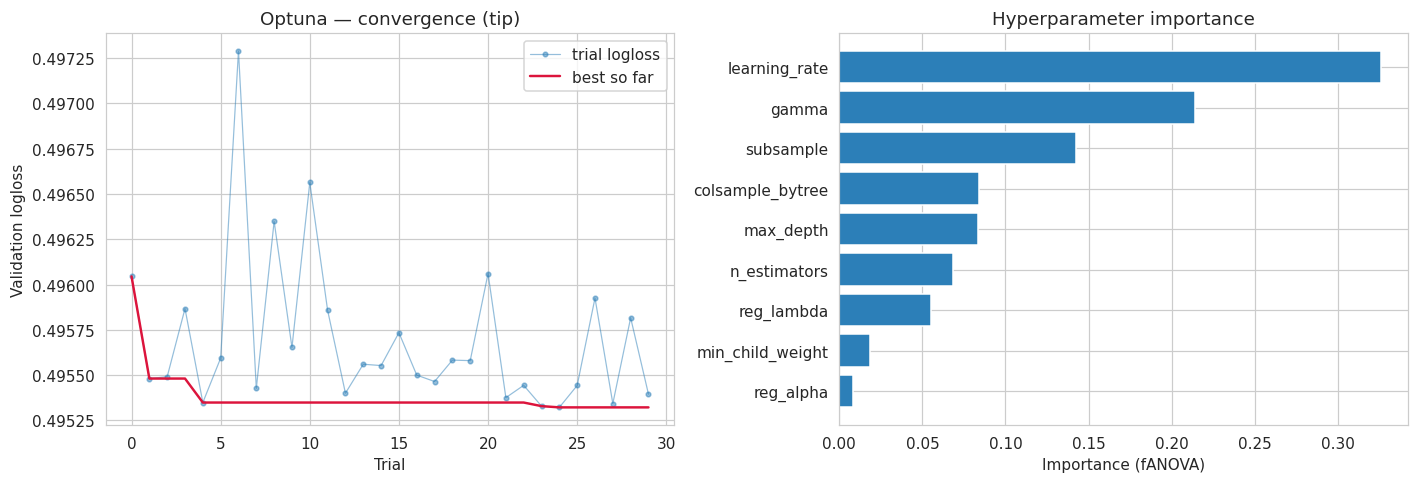

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

trials_df = study.trials_dataframe()

axes[0].plot(trials_df["number"], trials_df["value"], marker="o", markersize=3,
             linewidth=0.8, color="#2c7fb8", alpha=0.5, label="trial logloss")
axes[0].plot(trials_df["number"], trials_df["value"].cummin(),
             color="crimson", linewidth=1.6, label="best so far")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Validation logloss")
axes[0].set_title("Optuna — convergence (tip)")
axes[0].legend(loc="upper right")

try:

    importances = optuna.importance.get_param_importances(study)
    imp_df = pd.Series(importances).sort_values()

    axes[1].barh(imp_df.index, imp_df.values, color="#2c7fb8")
    axes[1].set_xlabel("Importance (fANOVA)")
    axes[1].set_title("Hyperparameter importance")

except Exception as e:

    axes[1].text(0.5, 0.5, f"importance unavailable\n({type(e).__name__})",
                 ha="center", va="center", transform=axes[1].transAxes)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "optuna_search.png")

plt.show()

## 13. K-Fold Cross-Validation with Best Params

Evaluate the winning Optuna config on the full 1.5M `eval_sample` using `CV_FOLDS`-fold CV. Per-fold metrics include logloss (calibration), AUC (ranking), AP (PR-curve area), Brier score (calibration), and binary classification metrics at the default threshold. Final reported metric is mean ± std across folds.

In [ ]:
final_params = {
    **study.best_params,
    "objective":          "binary:logistic",
    "eval_metric":        "logloss",
    "tree_method":        "hist",
    "device":             XGB_DEVICE,
    "enable_categorical": True,
    "random_state":       SEED,
    "verbosity":          0,
}

X_all = eval_sample[ALL_FEATURES]
y_all = eval_sample[TARGET]

kfold = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
fold_metrics = []

for fold_i, (tr_idx, va_idx) in enumerate(kfold.split(X_all), start=1):

    X_tr, X_va = X_all.iloc[tr_idx], X_all.iloc[va_idx]
    y_tr, y_va = y_all.iloc[tr_idx], y_all.iloc[va_idx]

    model = xgb.XGBClassifier(**final_params, n_jobs=-1)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

    proba = model.predict_proba(X_va)[:, 1]
    pred = (proba >= DEFAULT_THRESHOLD).astype(int)

    fold_metrics.append({
        "fold":     fold_i,
        "logloss":  float(log_loss(y_va, proba)),
        "auc":      float(roc_auc_score(y_va, proba)),
        "ap":       float(average_precision_score(y_va, proba)),
        "brier":    float(brier_score_loss(y_va, proba)),
        "accuracy": float(accuracy_score(y_va, pred)),
        "precision":float(precision_score(y_va, pred, zero_division=0)),
        "recall":   float(recall_score(y_va, pred, zero_division=0)),
        "f1":       float(f1_score(y_va, pred, zero_division=0)),
    })

    fm = fold_metrics[-1]

    print(f"  Fold {fold_i}/{CV_FOLDS} — logloss {fm['logloss']:.4f} | "
          f"AUC {fm['auc']:.4f} | AP {fm['ap']:.4f} | Brier {fm['brier']:.4f}")

cv_df = pd.DataFrame(fold_metrics)
cv_summary = cv_df.agg(["mean", "std"]).round(4)

print("\n" + "=" * 60)
print(f" {CV_FOLDS}-FOLD CV SUMMARY")
print("=" * 60)
print(f"  Logloss  : {cv_summary.loc['mean', 'logloss']:.4f} ± {cv_summary.loc['std', 'logloss']:.4f}")
print(f"  AUC      : {cv_summary.loc['mean', 'auc']:.4f} ± {cv_summary.loc['std', 'auc']:.4f}")
print(f"  AP       : {cv_summary.loc['mean', 'ap']:.4f} ± {cv_summary.loc['std', 'ap']:.4f}")
print(f"  Brier    : {cv_summary.loc['mean', 'brier']:.4f} ± {cv_summary.loc['std', 'brier']:.4f}")
print(f"  Accuracy : {cv_summary.loc['mean', 'accuracy']:.4f} ± {cv_summary.loc['std', 'accuracy']:.4f}")
print(f"  F1       : {cv_summary.loc['mean', 'f1']:.4f} ± {cv_summary.loc['std', 'f1']:.4f}")

cv_df.to_csv(METRICS_DIR / "kfold_cv_metrics.csv", index=False)

  Fold 1/5 — logloss 0.4969 | AUC 0.6192 | AP 0.8433 | Brier 0.1598
  Fold 2/5 — logloss 0.4944 | AUC 0.6216 | AP 0.8456 | Brier 0.1588
  Fold 3/5 — logloss 0.4942 | AUC 0.6228 | AP 0.8463 | Brier 0.1588
  Fold 4/5 — logloss 0.4958 | AUC 0.6223 | AP 0.8455 | Brier 0.1594
  Fold 5/5 — logloss 0.4958 | AUC 0.6241 | AP 0.8454 | Brier 0.1595

 5-FOLD CV SUMMARY
  Logloss  : 0.4954 ± 0.0011
  AUC      : 0.6220 ± 0.0018
  AP       : 0.8452 ± 0.0011
  Brier    : 0.1593 ± 0.0005
  Accuracy : 0.7935 ± 0.0007
  F1       : 0.8830 ± 0.0004


## 14. Final Model — Held-Out 20% + Save

Final model on a stratified 80/20 split and **save it as `xgb_v2_tip.json`** — the exact filename `gridrunners_demo.py` expects.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)

model_final = xgb.XGBClassifier(**final_params, n_jobs=-1)
model_final.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_proba = model_final.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= DEFAULT_THRESHOLD).astype(int)


logloss_v2 = float(log_loss(y_test, y_proba))
auc_v2 = float(roc_auc_score(y_test, y_proba))
ap_v2 = float(average_precision_score(y_test, y_proba))
brier_v2 = float(brier_score_loss(y_test, y_proba))
acc_v2 = float(accuracy_score(y_test, y_pred))
f1_v2 = float(f1_score(y_test, y_pred))

print(f"v2 tuned tip (held-out 20%):")
print(f"  Logloss  : {logloss_v2:.4f}")
print(f"  AUC      : {auc_v2:.4f}")
print(f"  AP       : {ap_v2:.4f}")
print(f"  Brier    : {brier_v2:.4f}")
print(f"  Accuracy : {acc_v2:.4f}  (at threshold {DEFAULT_THRESHOLD})")
print(f"  F1       : {f1_v2:.4f}  (at threshold {DEFAULT_THRESHOLD})")

# ── Save in the format gridrunners_demo.py loads ─────────────────────────────
# Streamlit does:  booster = xgb.Booster(); booster.load_model(str(path))
#                  proba = booster.predict(DMatrix(features, enable_categorical=True))[0]
# For binary:logistic, Booster.predict returns the probability directly — no
# sigmoid wrapping needed.

model_path = OUTPUT_DIR / "xgb_v2_tip.json"
model_final.get_booster().save_model(str(model_path))

print(f"\n✓ Model saved to : {model_path}")
print(f"  Copy this file into ./models/ alongside xgb_v2_fare.json for the demo to load it.")

v2 tuned tip (held-out 20%):
  Logloss  : 0.4959
  AUC      : 0.6209
  AP       : 0.8444
  Brier    : 0.1594
  Accuracy : 0.7934  (at threshold 0.5)
  F1       : 0.8829  (at threshold 0.5)

✓ Model saved to : /content/drive/MyDrive/DSCI 592/v2_tuned_tip/xgb_v2_tip.json
  Copy this file into ./models/ alongside xgb_v2_fare.json for the demo to load it.


## 15. Check — Round-Trip Load + Predict

Reload the saved booster the way the Streamlit app does, run a prediction on a single test row, and verify the output matches the in-memory model. Same insurance policy as the duration notebook — catches categorical encoding drift, feature-name reordering, and the `binary:logistic` raw-vs-probability output convention.

In [ ]:
booster_reloaded = xgb.Booster()
booster_reloaded.load_model(str(model_path))

one_row = X_test.iloc[[0]]
dmat = xgb.DMatrix(one_row, enable_categorical=True)

# booster.predict for binary:logistic returns probability by default

proba_from_disk = float(booster_reloaded.predict(dmat)[0])
proba_in_memory = float(model_final.predict_proba(one_row)[0, 1])

print(f"Probability from in-memory model : {proba_in_memory:.6f}")
print(f"Probability from reloaded booster: {proba_from_disk:.6f}")
print(f"Difference                        : {abs(proba_in_memory - proba_from_disk):.2e}")

assert abs(proba_in_memory - proba_from_disk) < 1e-5, "Serialization round-trip mismatch!"

print("\n✓ Round-trip passed — Streamlit will see the same probabilities this notebook does.")
print(f"  (Streamlit wrapper clips to [0, 1], matching the displayed format `{{:.0%}}`)")

Probability from in-memory model : 0.794986
Probability from reloaded booster: 0.794986
Difference                        : 5.96e-08

✓ Round-trip passed — Streamlit will see the same probabilities this notebook does.
  (Streamlit wrapper clips to [0, 1], matching the displayed format `{:.0%}`)


## 16. ROC + Precision-Recall Curves

- **ROC curve**: TPR vs FPR across all thresholds. AUC = probability that a random positive ranks above a random negative.
- **PR curve**: precision vs recall across all thresholds. AP = area under PR curve. More informative than ROC when classes are imbalanced (less critical here since we're ~65/35).


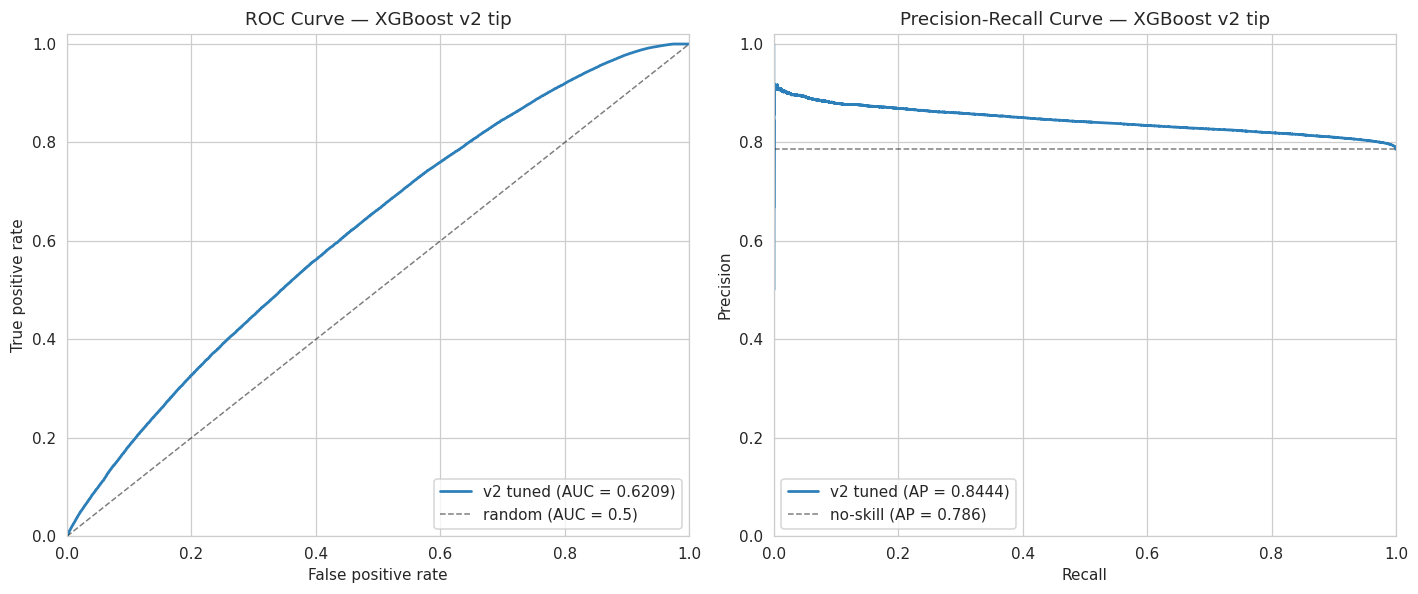

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ROC

fpr, tpr, _ = roc_curve(y_test, y_proba)

axes[0].plot(fpr, tpr, color="#2c7fb8", linewidth=1.8, label=f"v2 tuned (AUC = {auc_v2:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1.0, alpha=0.5, label="random (AUC = 0.5)")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC Curve — XGBoost v2 tip")
axes[0].legend(loc="lower right")
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1.02)

# PR
prec, rec, _ = precision_recall_curve(y_test, y_proba)
baseline_pr = y_test.mean()

axes[1].plot(rec, prec, color="#2c7fb8", linewidth=1.8, label=f"v2 tuned (AP = {ap_v2:.4f})")
axes[1].axhline(baseline_pr, color="k", linestyle="--", linewidth=1.0, alpha=0.5,
                label=f"no-skill (AP = {baseline_pr:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve — XGBoost v2 tip")
axes[1].legend(loc="lower left")
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.02)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "v2_roc_pr.png")

plt.show()

## 17. **Calibration Plot**

Given the cash-tip data limitation, *the predicted probability is honest with respect to what the data contains.*


- The model's predicted probabilities are sorted and split into 10 deciles.
- For each decile, plot mean predicted probability (x) against observed positive rate (y).
- A perfectly calibrated classifier sits on the diagonal $y = x$.
- Above the diagonal -> model is under-confident (true rate is higher than predicted).
- Below the diagonal -> model is over-confident (true rate is lower than predicted).

Two numeric calibration scores:
- **Brier score** — mean squared error between predicted probabilities and observed labels.y.
- **ECE (Expected Calibration Error)** — the average gap between predicted and observed across bins, weighted by bin size.

Brier score : 0.1594
ECE         : 0.0019  (10-bin equal-width)


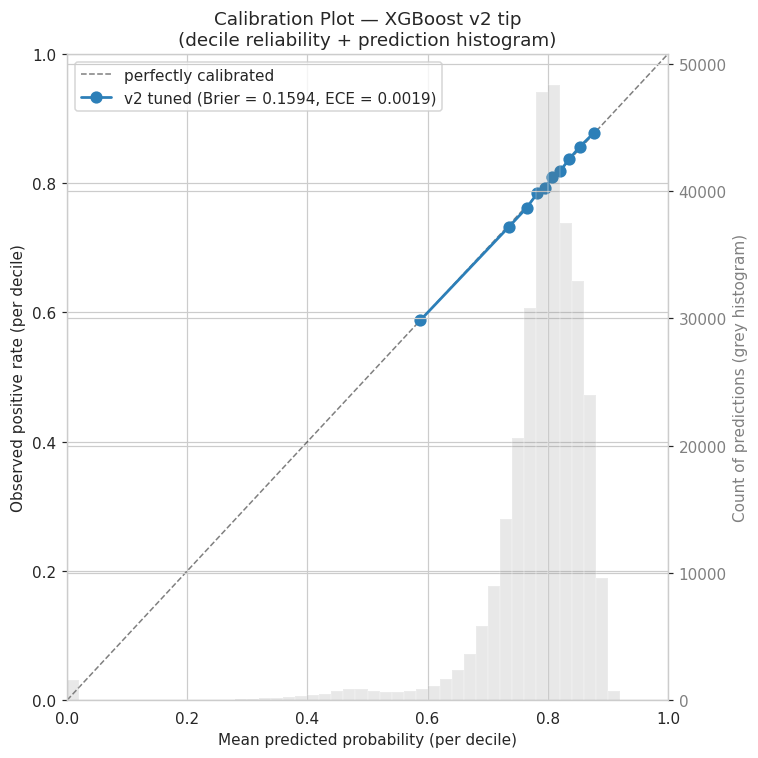


Reliability table:
 mean_predicted_prob  observed_pos_rate     gap
              0.5882             0.5882  0.0000
              0.7357             0.7329 -0.0028
              0.7647             0.7617 -0.0030
              0.7827             0.7845  0.0019
              0.7954             0.7926 -0.0028
              0.8070             0.8091  0.0022
              0.8200             0.8182 -0.0018
              0.8359             0.8375  0.0016
              0.8528             0.8561  0.0032
              0.8768             0.8779  0.0011


In [ ]:
def expected_calibration_error(y_true, y_proba, n_bins: int = 10) -> float:


    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_idx = np.digitize(y_proba, bins[1:-1])

    ece = 0.0
    n = len(y_true)

    for b in range(n_bins):

        mask = bin_idx == b

        if mask.any():
            ece += (mask.sum() / n) * abs(y_true[mask].mean() - y_proba[mask].mean())

    return float(ece)

ece_v2 = expected_calibration_error(np.asarray(y_test), y_proba, n_bins=10)

print(f"Brier score : {brier_v2:.4f}")
print(f"ECE         : {ece_v2:.4f}  (10-bin equal-width)")

# diagram

prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(7, 7))

ax.plot([0, 1], [0, 1], "k--", linewidth=1.0, alpha=0.5, label="perfectly calibrated")
ax.plot(prob_pred, prob_true, marker="o", color="#2c7fb8", linewidth=1.8, markersize=7,
        label=f"v2 tuned (Brier = {brier_v2:.4f}, ECE = {ece_v2:.4f})")

# Histogram of predicted probabilitie

ax2 = ax.twinx()

ax2.hist(y_proba, bins=50, range=(0, 1), alpha=0.18, color="grey")
ax2.set_ylabel("Count of predictions (grey histogram)", color="grey")
ax2.tick_params(axis="y", labelcolor="grey")

ax.set_xlabel("Mean predicted probability (per decile)")
ax.set_ylabel("Observed positive rate (per decile)")
ax.set_title("Calibration Plot — XGBoost v2 tip\n(decile reliability + prediction histogram)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(loc="upper left")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "v2_calibration.png")

plt.show()

print(f"\nReliability table:")

print(pd.DataFrame({
    "mean_predicted_prob": prob_pred.round(4),
    "observed_pos_rate":   prob_true.round(4),
    "gap":                 (prob_true - prob_pred).round(4),
}).to_string(index=False))

## Feature Importance

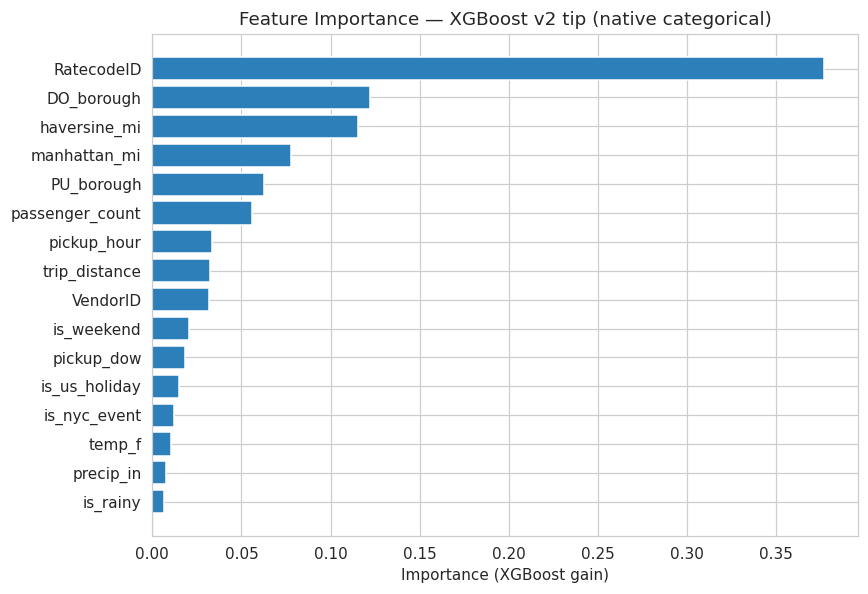

,feature,importance
15,RatecodeID,0.3770
14,DO_borough,0.1223
13,haversine_mi,0.1152
12,manhattan_mi,0.0781
11,PU_borough,0.0629
10,passenger_count,0.0562
9,pickup_hour,0.0337
8,trip_distance,0.0322
7,VendorID,0.0318
6,is_weekend,0.0203


In [ ]:
imp_df = (pd.DataFrame({
    "feature": model_final.feature_names_in_,
    "importance": model_final.feature_importances_,
}).sort_values("importance", ascending=True).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.barh(imp_df["feature"], imp_df["importance"], color="#2c7fb8")
ax.set_xlabel("Importance (XGBoost gain)")
ax.set_title("Feature Importance — XGBoost v2 tip (native categorical)")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "v2_feature_importance.png")

plt.show()

imp_df.sort_values("importance", ascending=False).round(4)

## 19. Threshold Analysis + Borough Breakdown

1. **Threshold sweep** — accuracy, precision, recall, F1 across thresholds. The Streamlit UI displays the raw probability and never thresholds.
2. **Borough-pair tip rate** — observed vs predicted tip rate by (PU, DO) borough. Surfaces where the model's borough categoricals are doing useful work versus where the borough signal is weak.

Best F1 threshold : 0.45  (F1 = 0.8831)


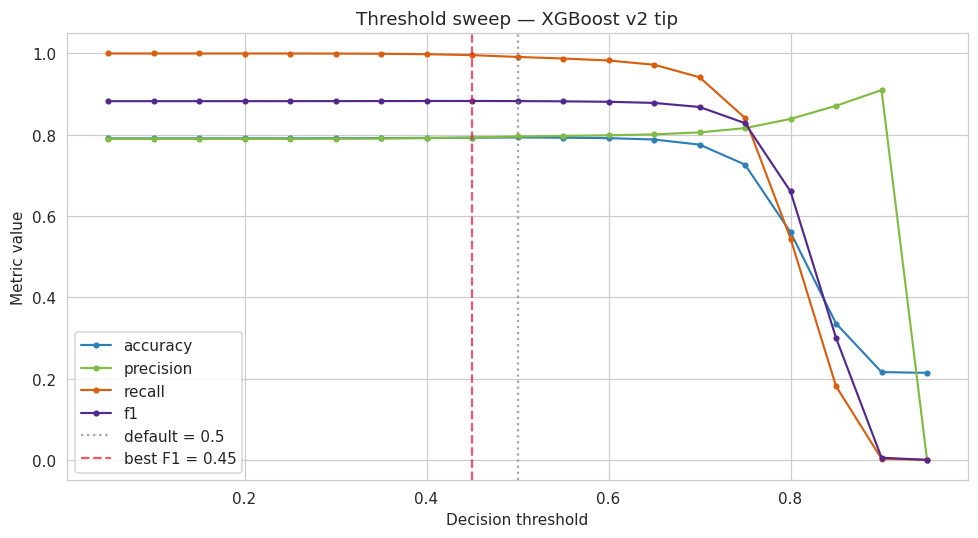

In [ ]:
thresholds = np.linspace(0.05, 0.95, 19)
sweep = []

for t in thresholds:

    pred_t = (y_proba >= t).astype(int)

    sweep.append({
        "threshold": float(t),
        "accuracy":  float(accuracy_score(y_test, pred_t)),
        "precision": float(precision_score(y_test, pred_t, zero_division=0)),
        "recall":    float(recall_score(y_test, pred_t, zero_division=0)),
        "f1":        float(f1_score(y_test, pred_t, zero_division=0)),
        "positives": int(pred_t.sum()),
    })

sweep_df = pd.DataFrame(sweep)
sweep_df.to_csv(METRICS_DIR / "threshold_sweep.csv", index=False)

best_f1_row = sweep_df.loc[sweep_df["f1"].idxmax()]

print(f"Best F1 threshold : {best_f1_row['threshold']:.2f}  (F1 = {best_f1_row['f1']:.4f})")

fig, ax = plt.subplots(figsize=(9, 5))

for col, color in [("accuracy", "#2c7fb8"), ("precision", "#7fbc41"),
                    ("recall", "#d95f0e"),   ("f1", "#54278f")]:
    
    ax.plot(sweep_df["threshold"], sweep_df[col], marker="o", markersize=3,
            label=col, color=color, linewidth=1.4)
    
ax.axvline(DEFAULT_THRESHOLD, color="grey", linestyle=":", alpha=0.7,
           label=f"default = {DEFAULT_THRESHOLD}")
ax.axvline(best_f1_row["threshold"], color="crimson", linestyle="--", alpha=0.7,
           label=f"best F1 = {best_f1_row['threshold']:.2f}")

ax.set_xlabel("Decision threshold")
ax.set_ylabel("Metric value")
ax.set_title("Threshold sweep — XGBoost v2 tip")
ax.legend(loc="lower left")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "v2_threshold_sweep.png")

plt.show()

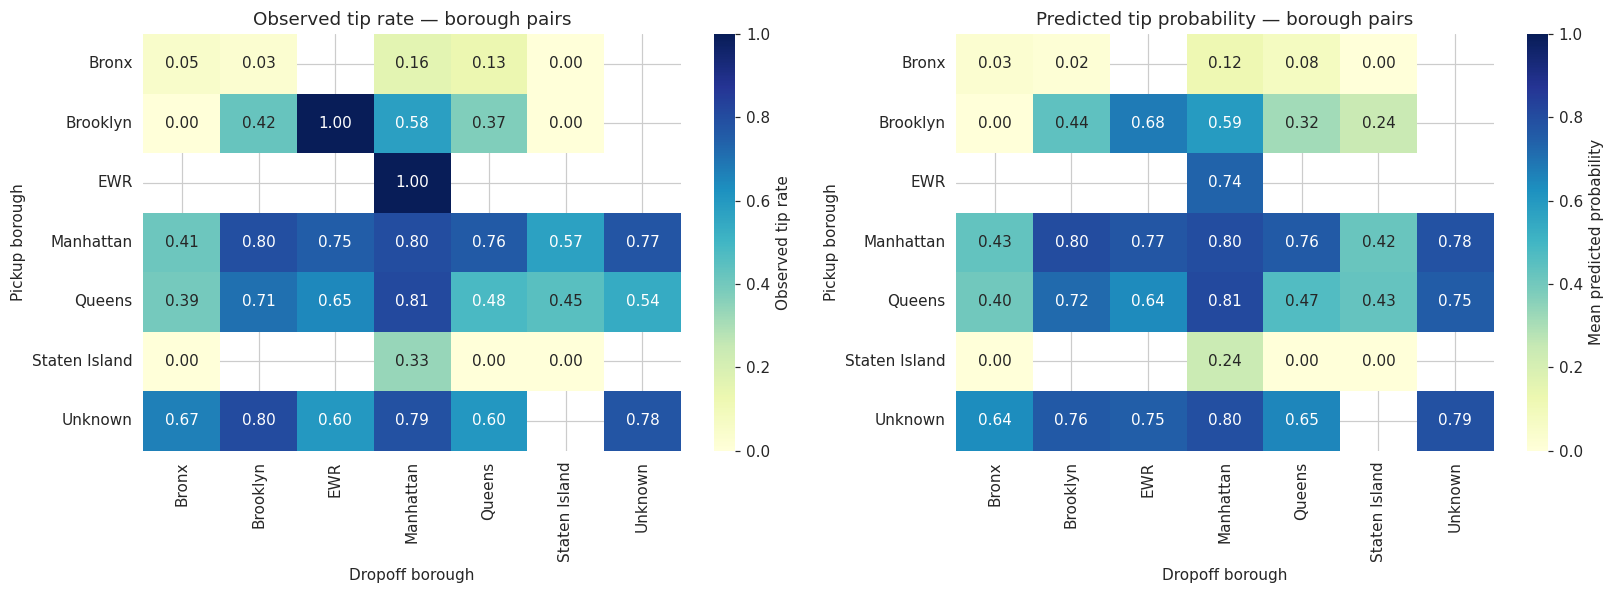


Mean |observed − predicted| by pickup borough (averaged across dropoff):
pu
EWR              0.2630
Brooklyn         0.1088
Unknown          0.0483
Queens           0.0407
Manhattan        0.0306
Bronx            0.0262
Staten Island    0.0253


In [ ]:
diag = pd.DataFrame({
    "actual":   np.asarray(y_test),
    "proba":    y_proba,
    "pu":       X_test[COL["pu_borough"]].astype(str).to_numpy(),
    "do":       X_test[COL["do_borough"]].astype(str).to_numpy(),
})

observed = diag.pivot_table(index="pu", columns="do", values="actual", aggfunc="mean")
predicted = diag.pivot_table(index="pu", columns="do", values="proba", aggfunc="mean")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.heatmap(observed, annot=True, fmt=".2f", cmap="YlGnBu",
            cbar_kws={"label": "Observed tip rate"}, ax=axes[0], vmin=0, vmax=1)

axes[0].set_xlabel("Dropoff borough"); axes[0].set_ylabel("Pickup borough")
axes[0].set_title("Observed tip rate — borough pairs")

sns.heatmap(predicted, annot=True, fmt=".2f", cmap="YlGnBu",
            cbar_kws={"label": "Mean predicted probability"}, ax=axes[1], vmin=0, vmax=1)

axes[1].set_xlabel("Dropoff borough"); axes[1].set_ylabel("Pickup borough")
axes[1].set_title("Predicted tip probability — borough pairs")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "v2_borough_tip_rate.png")

plt.show()

gap = (observed - predicted).abs().round(3)

print("\nMean |observed − predicted| by pickup borough (averaged across dropoff):")
print(gap.mean(axis=1).round(4).sort_values(ascending=False).to_string())

## 20. Full-Dataset Run *(gated — set `USE_FULL_DATASET = True` to enable)*

Retrain on the entire cleaned parquet using `xgb.QuantileDMatrix` for memory efficiency. Overwrites `xgb_v2_tip.json` with the full-data booster (the production artifact).

In [ ]:
if USE_FULL_DATASET:

    print(f"Training on full cleaned parquet: {len(df_clean):,} rows")

    X_full = df_clean[ALL_FEATURES]
    y_full = df_clean[TARGET]

    X_tr, X_te, y_tr, y_te = train_test_split(X_full, y_full, test_size=0.1, random_state=SEED, stratify=y_full)

    dtrain = xgb.QuantileDMatrix(X_tr, label=y_tr, enable_categorical=True)
    dtest  = xgb.QuantileDMatrix(X_te, label=y_te, enable_categorical=True, ref=dtrain)

    booster_full = xgb.train(
        params={k: v for k, v in final_params.items() if k != "n_estimators"},
        dtrain=dtrain,
        num_boost_round=final_params["n_estimators"],
        evals=[(dtest, "test")],
        early_stopping_rounds=50,
        verbose_eval=100,
    )

    proba_full = booster_full.predict(dtest)
    logloss_full = float(log_loss(y_te, proba_full))
    auc_full = float(roc_auc_score(y_te, proba_full))
    brier_full = float(brier_score_loss(y_te, proba_full))

    print(f"\nFull-dataset — Logloss: {logloss_full:.4f} | AUC: {auc_full:.4f} | Brier: {brier_full:.4f}")

    booster_full.save_model(str(OUTPUT_DIR / "xgb_v2_tip.json"))

    print(f"✓ Overwrote {OUTPUT_DIR / 'xgb_v2_tip.json'} with full-data booster.")

else:
    print("Full-dataset run skipped. Flip USE_FULL_DATASET=True in Section 2 to enable.")
    
    logloss_full = auc_full = brier_full = None

Full-dataset run skipped. Flip USE_FULL_DATASET=True in Section 2 to enable.


## 21. Summary

In [ ]:
summary = {
    "v2_tuned_holdout":  {
        "logloss":  logloss_v2, "auc": auc_v2, "ap": ap_v2,
        "brier":    brier_v2,   "ece": ece_v2,
        "accuracy": acc_v2,     "f1":  f1_v2,
        "threshold": DEFAULT_THRESHOLD,
    },
    "v2_tuned_kfold": {
        "k": CV_FOLDS,
        **{f"{m}_mean": float(cv_summary.loc["mean", m])
           for m in ["logloss", "auc", "ap", "brier", "accuracy", "f1"]},
        **{f"{m}_std":  float(cv_summary.loc["std",  m])
           for m in ["logloss", "auc", "ap", "brier", "accuracy", "f1"]},
    },
    "v2_tuned_full":  ({"logloss": logloss_full, "auc": auc_full, "brier": brier_full}
                       if USE_FULL_DATASET else None),
    "best_params":    study.best_params,
    "n_trials":       N_TRIALS,
    "sample_size":    SAMPLE_SIZE,
    "tuning_sample":  TUNING_SAMPLE,
    "features":       ALL_FEATURES,
    "dist_bounds":    [DIST_MIN, DIST_MAX],
    "class_balance":  float(eval_sample[TARGET].mean()),
    "seed":           SEED,
    "model_artifact": "xgb_v2_tip.json",
    "target_interpretation": (
        "P(observed tip > 0 | features) — joint of P(card payment) × P(tip|card). "
        "Trained on full dataset (no payment-type filter). See Section 22."
    ),
}

with open(METRICS_DIR / "v2_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("=" * 64)
print(" v2 TUNED TIP MODEL — DECK SUMMARY")
print("=" * 64)
print(f"  v2 tuned (held-out)   : Logloss {logloss_v2:.4f}  | AUC {auc_v2:.4f}  | Brier {brier_v2:.4f}  | ECE {ece_v2:.4f}")
print(f"  v2 tuned ({CV_FOLDS}-fold CV)  : Logloss {cv_summary.loc['mean','logloss']:.4f} "
      f"± {cv_summary.loc['std','logloss']:.4f}  |  AUC {cv_summary.loc['mean','auc']:.4f} "
      f"± {cv_summary.loc['std','auc']:.4f}")

if USE_FULL_DATASET:
    print(f"  v2 tuned (full data)  : Logloss {logloss_full:.4f} | AUC {auc_full:.4f} | Brier {brier_full:.4f}")
    
print()
print(f"  Class balance    : P(tipped=1) = {eval_sample[TARGET].mean():.4f}")
print(f"  Model artifact   : {OUTPUT_DIR / 'xgb_v2_tip.json'}")
print(f"  Figures saved to : {FIGURE_DIR}")
print(f"  Metrics saved to : {METRICS_DIR}")
print()
print(f"  Next step: copy xgb_v2_tip.json into the Streamlit MODEL_DIR")
print(f"  alongside xgb_v2_fare.json. Restart the demo and the Tip likelihood")
print(f"  metric tile will populate.")

 v2 TUNED TIP MODEL — DECK SUMMARY
  v2 tuned (held-out)   : Logloss 0.4959  | AUC 0.6209  | Brier 0.1594  | ECE 0.0019
  v2 tuned (5-fold CV)  : Logloss 0.4954 ± 0.0011  |  AUC 0.6220 ± 0.0018

  Class balance    : P(tipped=1) = 0.7859
  Model artifact   : /content/drive/MyDrive/DSCI 592/v2_tuned_tip/xgb_v2_tip.json
  Figures saved to : /content/drive/MyDrive/DSCI 592/v2_tuned_tip/figures
  Metrics saved to : /content/drive/MyDrive/DSCI 592/v2_tuned_tip/metrics

  Next step: copy xgb_v2_tip.json into the Streamlit MODEL_DIR
  alongside xgb_v2_fare.json. Restart the demo and the Tip likelihood
  metric tile will populate.


## 22. Methodology

The `tipped` target is derived from TLC `tip_amount`, which is **only populated for credit-card transactions** in yellow taxi data. Cash tips happen but are never recorded — they're a measurement gap in the source, not a property of the riders.

Chose to train on the full dataset anyway, with no `payment_type` filter, because:

1. **Customer-facing question.** At booking time, payment method is the rider's choice and not predictable a priori. The UI asks "do trips like this end up tipped?" — that should not prejudge how the rider will pay.
2. **Avoiding a hidden assumption.** Filtering to card-only trips and reporting P(tip | card) bakes in the unstated condition "you will pay by card.".

**What the model has actually learned.** The predicted probability decomposes algebraically as:

$$ P(\text{recorded tip} > 0 \mid \text{features}) \;=\; \underbrace{P(\text{card payment} \mid \text{features})}_{\text{payment behavior}} \;\times\; \underbrace{P(\text{tip} > 0 \mid \text{card payment, features})}_{\text{conditional tipping behavior}} $$

XGBoost doesn't separate these factors:

> *"Given a trip with these characteristics, what fraction of historically similar trips ended in a recorded tip?"*

This quantity is bounded above by the credit-card adoption rate for that trip type. A short outer-borough hop where cash is more common might cap around 40%; an airport run dominated by card payments approaches 95%. The **relative ordering** across zones, times, and trip types remains meaningful — the absolute scale captures both payment behavior and tipping behavior jointly.

If the model's predicted probabilities match the observed positive rates on the test set (i.e., the reliability diagram tracks the diagonal), can honestly say the model is calibrated to what the data contains. Though not claiming to predict "true tipping rate including cash" — but able to predict "observed recorded-tip rate," and the calibration plot is the empirical receipt that the prediction matches that quantity.

**What we'd do differently with better data.** Two-stage decomposition: train one model for P(card | features) and a second for P(tip | card, features), then display either the joint or the conditional depending on which question the user is asking. We sketch this as a "next steps" item below.

## 23. Next Steps

- `demand_v2_tuned.ipynb` — count regression on pickups per `(PU_borough, date, hour)`. Needs a target-aggregation cell up front; the rest mirrors this structure.

**Tip-model refinements:**
- **Two-stage decomposition.** Separate classifiers for P(card | features) and P(tip | card, features). Display the joint by default in the UI but expose a toggle to show the conditional — gives users both "what will happen" and "what would happen if you paid by card."
- **Generous-tip head.** A secondary classifier on `(tip_amount / fare_amount) >= 0.20` among card-paid trips. Surfaces the more interesting behavioral signal (commuter vs tourist tipping patterns) once the noise from payment-method conflation is removed.
- **Calibration refinement.** If the reliability diagram in Section 17 shows systematic miscalibration (most likely under-confidence in the 0.4–0.6 range), add a Platt-scaling or isotonic-regression calibration layer trained on a held-out validation set. The Streamlit wrapper would call the calibrator on the booster output before display.
- **Promote `PU_borough`/`DO_borough` to `PULocationID`/`DOLocationID`** for finer spatial resolution — same enhancement listed in the fare and duration notebooks.